## [CNN Autoencoder](https://www.digitalocean.com/community/tutorials/convolutional-autoencoder)

In [1]:
#!/home/ee577/miniconda3/envs/ee577/bin/python
# From https://www.digitalocean.com/community/tutorials/convolutional-autoencoder

import os
import sys
import torch
import numpy as np
import torch.nn as nn
from pathlib import Path
import torchvision.datasets as Datasets
import torchvision.transforms as transforms

pkg_path = str(Path(os.path.abspath('')).parent.absolute())
sys.path.insert(0, pkg_path)

from src import *

# Load config file
config = global_config.config

#  configuring device
if torch.cuda.is_available():
    config.device = 'cuda:2' # use GPU #3
    print('Running on the GPU')
else:
    config.device = 'cpu'
    print('Running on the CPU')


2025-03-02 17:58:32.645384: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1740967112.657415 1563758 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1740967112.660965 1563758 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-02 17:58:32.674903: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Running on the GPU


Encoder:
Sequential(
  (0): Conv2d(1, 8, kernel_size=(1, 1), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): Conv2d(8, 8, kernel_size=(1, 1), stride=(1, 1), padding=(1, 1))
  (3): ReLU()
  (4): Conv2d(8, 16, kernel_size=(1, 1), stride=(2, 2), padding=(1, 1))
  (5): ReLU()
  (6): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), padding=(1, 1))
  (7): ReLU()
  (8): Conv2d(16, 32, kernel_size=(1, 1), stride=(2, 2), padding=(1, 1))
  (9): ReLU()
  (10): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), padding=(1, 1))
  (11): ReLU()
  (12): Flatten(start_dim=1, end_dim=-1)
  (13): Linear(in_features=139392, out_features=8000, bias=True)
  (14): ReLU()
  (15): Linear(in_features=8000, out_features=4000, bias=True)
  (16): ReLU()
  (17): Linear(in_features=4000, out_features=2000, bias=True)
  (18): ReLU()
)

Decoder:
Sequential(
  (0): Linear(in_features=2000, out_features=4000, bias=True)
  (1): ReLU()
  (2): Linear(in_features=4000, out_features=8000, bias=True)
  (3): ReLU()
  (4): 

100%|██████████| 1/1 [00:01<00:00,  1.00s/it]


validating...


100%|██████████| 1/1 [00:00<00:00, 13.01it/s]


training_loss: 0.363 validation_loss: 0.3544


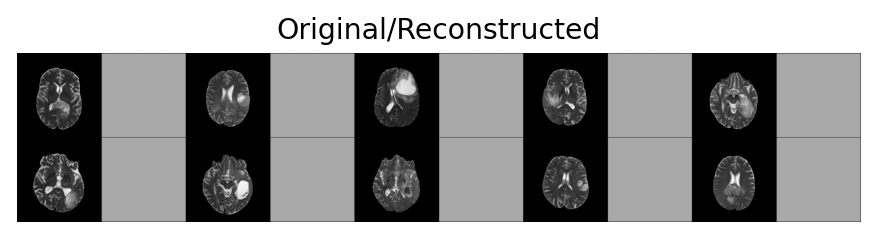

Epoch 2/20
training...


  0%|          | 0/1 [00:00<?, ?it/s]


OutOfMemoryError: CUDA out of memory. Tried to allocate 4.15 GiB. GPU 2 has a total capacity of 47.50 GiB of which 3.52 GiB is free. Including non-PyTorch memory, this process has 43.96 GiB memory in use. Of the allocated memory 39.25 GiB is allocated by PyTorch, and 4.21 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [2]:
# Params for loading data
gen_params = {
        'data_dir': config.upenn_out_dir,
        'csv_dir': config.upenn_dir,
        'modality': ['mods'],
        'n_channels': 5,
        'seed': config.seed,
        'to_augment': False,
        'make_augment': False,
        'to_encode': False,
        'to_slice': False,
        'to_3D_slice': False,
        'use_clinical': False,
        'augment_types': None,
        'batch_sz': config.load_batch_size,
}

#  generate training and testing dataloader
full_dl = datasets.load_upenn_2d_full(gen_params)

#  select modality to train CNN
modality = 'T2' # choose from ['T2', 'FLAIR', 'T1', 'T1GD']
modality_id = helpers.modalities['struct'].index(modality)

#  extracting training and validation images
full_images, full_labels = helpers.extract_images(full_dl, [modality], labels=True)

#  extracting training and validation images
split_idx = int(0.8*full_images.shape[0])

training_images = full_images[0:split_idx]
validation_images = full_images[split_idx:]

#  extracting test images for visualization purposes
test_images = validation_images[0:10]
    
#  creating pytorch datasets
training_data = datasets.CustomDataset(training_images, transforms=transforms.Compose([]))

validation_data = datasets.CustomDataset(validation_images, transforms=transforms.Compose([]))

test_data = datasets.CustomDataset(test_images, transforms=transforms.Compose([]))
 
#  training model
model = models.ConvolutionalAutoencoder(models.UPENNAutoencoder(
    models.UPENNEncoder(in_channels=1,out_channels=8,img_len=240,latent_dim=2000),
    models.UPENNDecoder(in_channels=1,out_channels=8,img_len=240,latent_dim=2000)),
    in_channels=1,
    img_len = 240)

log_dict = model.train(nn.MSELoss(), epochs=20, batch_size=128, 
    training_set=training_data, validation_set=validation_data, test_set=test_data)


In [ ]:


train_loss = np.asarray(log_dict['training_loss_per_batch'])
val_loss = np.asarray(log_dict['validation_loss_per_batch'])
num_batches = train_loss.shape[0]

plot_data.plot_line(np.arange(num_batches), train_loss, "train loss", 'Training loss per batch', 'batch number', 'training loss', save=True, fname="train_loss")
plot_data.plot_line(np.arange(num_batches), val_loss, "validation loss", 'validation loss per batch', 'batch number', 'validation loss', save=True, fname="val_loss")
